In [1]:
import pandas as pd
from pathlib import Path

In [114]:
BASE_DIR = Path("..").resolve()
INFO_PV_FILE = BASE_DIR/'data'/'InfoPV'/'power_station_metadata.csv'
generators = pd.read_csv(INFO_PV_FILE)
npts = 960

In [133]:
class PVShapeConverter:
    def __init__(self, generators:pd.DataFrame, PVid:int=1, npts:int=96):
        #Tratamento de quais curvas vão ser consideradas    
        if PVid > 51:
            PVid = PVid % 51
        elif PVid <= 0:
            print('WARNING: O número de id de entrada do PV foi', PVid, '\nO número de id de entrada do  PV deve ser igual ou maior que 1, portanto foi atribuído a ele o valor default')
            PVid=1
        
        self.npts = npts
        self.PVid = generators.iloc[PVid-1, 1]
        self.FILE_CSV = self.PVid + '.csv'
        self.CURVES_SOLAR_STATION_FILE = BASE_DIR/'data'/'InfoPV'/'solar_station'/self.FILE_CSV
        self.solar_station_curves = pd.read_csv(self.CURVES_SOLAR_STATION_FILE)
        self.datetime = self.solar_station_curves['datetime'].loc[:self.npts]
        self.PVirrad = self.solar_station_curves['poa_irradiance_wm2'].iloc[:self.npts] #Pega os valores de irradiância incidente no plano dos paineis.


In [143]:
conversor = PVShapeConverter(
    generators = generators, 
    PVid = 45, 
    npts = npts
)
conversor.PVirrad




0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
955   -1.135785
956   -0.850018
957   -1.320420
958   -1.003711
959   -0.917305
Name: poa_irradiance_wm2, Length: 960, dtype: float64

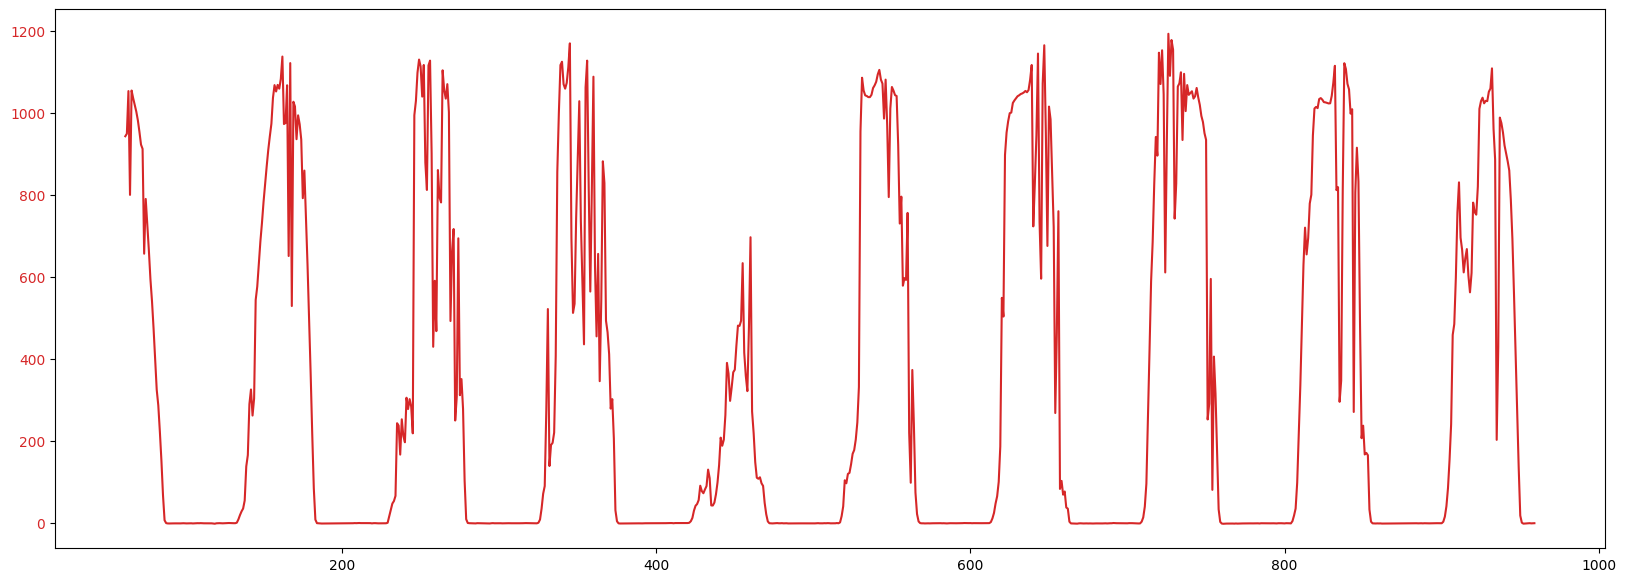

In [142]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Criação da figura com um tamanho um pouco maior para acomodar rótulos
fig, axs = plt.subplots(1, 1, figsize=(20, 7))

# --- PLOT 1: Temperatura e Irradiância ---
# Usar 'tab:red' (vermelho) para temperatura dá um bom contraste
linha1 = axs.plot(conversor.PVirrad, color='tab:red', linestyle='-')

axs.tick_params(axis='y', labelcolor='tab:red')


In [ ]:
# Pega todos os valores da segunda coluna e divide por 1000
valores = (irrad[irrad.columns[1]].values) / 1000

# Formata cada valor com 10 casas decimais, substituindo NaN por 0
valores_formatados = [
    "0.0" if pd.isna(v) or v == 0.0 else f"{v:.16f}"
    for v in valores
]

# Quantidade total de pontos
npts = len(valores_formatados)

# Cria a string no formato DSS
conteudo_dss = f"New LoadShape.MyShapePV1 npts={npts} minterval=1 mult=({', '.join(valores_formatados)})\n"

# Salva como arquivo .dss
nome_arquivo = "src/data/13Bus/LoadShapePV_2.dss"
with open(nome_arquivo, "w") as f:
    f.write(conteudo_dss)

print(f"Processamento concluído! {npts} pontos foram escritos no arquivo.")